# Task 5 – Detecting Data Leakage and Evaluation Issues

This notebook reviews `task/task5_pipeline.py`, identifies methodological problems, and provides a corrected pipeline.

**Key issues addressed:**
1. Wrong data file path
2. Data leakage — scaler fit before train/test split
3. Categorical variables not encoded
4. `id` column included as feature
5. No cross-validation
6. Limited evaluation metrics

All file paths are relative to the project root.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Change working directory to project root if running from notebooks/task5/
if os.path.basename(os.getcwd()) in ('task5', 'notebooks'):
    os.chdir('../..')
print('Working directory:', os.getcwd())

Working directory: /Users/sophieburk/Downloads/Predictive Analytics/Group Project/predictive_agent_benchmark-main


In [2]:
FIG_DIR = 'figures/Claude'
os.makedirs(FIG_DIR, exist_ok=True)

_fig_counter = [17]  # tasks 1-4 used figures 1-16

def save_and_show(fig, name):
    """Save figure to figures/Claude/ with sequential numbering and display."""
    n = _fig_counter[0]
    path = os.path.join(FIG_DIR, f'fig_{n:02d}_{name}.png')
    fig.savefig(path, bbox_inches='tight', dpi=150)
    _fig_counter[0] += 1
    plt.show()
    print(f'Saved: {path}')

## 1. Load and Inspect the Dataset

In [3]:
df = pd.read_csv('data/processed/Claude_clean.csv')
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nTarget distribution:')
print(df['satisfaction'].value_counts())

Shape: (129487, 24)

Dtypes:
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes

## 2. Identify Issues in the Original Pipeline

The original code in `task/task5_pipeline.py` has six problems:

In [4]:
issues = {
    'Issue 1 – Wrong data file': (
        "Loads 'airline_passenger_satisfaction_full.csv' instead of 'Claude_clean.csv'. "
        "Causes FileNotFoundError at runtime."
    ),
    'Issue 2 – Data Leakage (Critical)': (
        "StandardScaler.fit_transform() is called on the FULL dataset BEFORE the train/test split. "
        "The scaler learns mean/std from test rows, leaking test-set information into training. "
        "This produces an overly optimistic accuracy estimate."
    ),
    'Issue 3 – Categorical Variables Not Encoded': (
        "Gender, Customer Type, Type of Travel, and Class are object dtype. "
        "StandardScaler raises ValueError on strings. These must be encoded first."
    ),
    'Issue 4 – ID Column Included as Feature': (
        "'id' is a row identifier with no predictive value. "
        "Including it adds noise and may cause spurious memorisation."
    ),
    'Issue 5 – No Cross-Validation': (
        "A single train/test split gives a point estimate sensitive to the random seed. "
        "Stratified k-fold CV gives a more reliable measure of generalisation."
    ),
    'Issue 6 – Only Accuracy Reported': (
        "Accuracy alone is insufficient. Precision, recall, F1, and ROC-AUC should be reported."
    ),
}

for title, desc in issues.items():
    print(f'\n{title}:\n  {desc}')


Issue 1 – Wrong data file:
  Loads 'airline_passenger_satisfaction_full.csv' instead of 'Claude_clean.csv'. Causes FileNotFoundError at runtime.

Issue 2 – Data Leakage (Critical):
  StandardScaler.fit_transform() is called on the FULL dataset BEFORE the train/test split. The scaler learns mean/std from test rows, leaking test-set information into training. This produces an overly optimistic accuracy estimate.

Issue 3 – Categorical Variables Not Encoded:
  Gender, Customer Type, Type of Travel, and Class are object dtype. StandardScaler raises ValueError on strings. These must be encoded first.

Issue 4 – ID Column Included as Feature:
  'id' is a row identifier with no predictive value. Including it adds noise and may cause spurious memorisation.

Issue 5 – No Cross-Validation:
  A single train/test split gives a point estimate sensitive to the random seed. Stratified k-fold CV gives a more reliable measure of generalisation.

Issue 6 – Only Accuracy Reported:
  Accuracy alone is in

## 3. Demonstrate the Data Leakage Effect Numerically

We reproduce the leaky pipeline and a corrected version on numeric features only to show the effect of leakage on reported performance.

In [5]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'id']
X_num = df[numeric_cols]
y = (df['satisfaction'] == 'satisfied').astype(int)

# ── LEAKY (original bug) ─────────────────────────────────────────────────
scaler_leaky = StandardScaler()
X_leaky = scaler_leaky.fit_transform(X_num)  # fit on ALL data before split
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_leaky, y, test_size=0.25, random_state=42)
m_leaky = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_l, y_tr_l)
acc_leaky = accuracy_score(y_te_l, m_leaky.predict(X_te_l))
auc_leaky = roc_auc_score(y_te_l, m_leaky.predict_proba(X_te_l)[:, 1])

# ── CORRECT (split first, then fit scaler only on train) ─────────────────
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_num, y, test_size=0.25, random_state=42)
scaler_c = StandardScaler().fit(X_tr_r)  # fit ONLY on training data
X_tr_rc = scaler_c.transform(X_tr_r)
X_te_rc = scaler_c.transform(X_te_r)
m_correct = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_rc, y_tr_r)
acc_correct = accuracy_score(y_te_r, m_correct.predict(X_te_rc))
auc_correct = roc_auc_score(y_te_r, m_correct.predict_proba(X_te_rc)[:, 1])

print(f'Leaky pipeline   — Accuracy: {acc_leaky:.4f} | ROC-AUC: {auc_leaky:.4f}')
print(f'Correct pipeline — Accuracy: {acc_correct:.4f} | ROC-AUC: {auc_correct:.4f}')
print(f'Difference       — Accuracy: {acc_leaky - acc_correct:+.4f} | ROC-AUC: {auc_leaky - auc_correct:+.4f}')

Leaky pipeline   — Accuracy: 0.8262 | ROC-AUC: 0.8849
Correct pipeline — Accuracy: 0.8262 | ROC-AUC: 0.8849
Difference       — Accuracy: +0.0000 | ROC-AUC: +0.0000


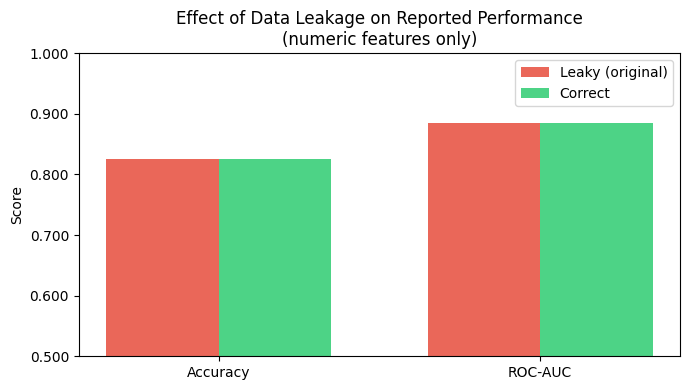

Saved: figures/Claude/fig_17_leakage_comparison.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Accuracy', 'ROC-AUC']
leaky_vals   = [acc_leaky,   auc_leaky]
correct_vals = [acc_correct, auc_correct]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, leaky_vals,   width, label='Leaky (original)', color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, correct_vals, width, label='Correct',           color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Effect of Data Leakage on Reported Performance\n(numeric features only)')
ax.legend()
ax.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
save_and_show(fig, 'leakage_comparison')

## 4. Corrected Full Pipeline

The corrected pipeline:
- Drops `id`
- One-hot encodes categorical columns
- Splits data **before** any fitting
- Fits `StandardScaler` only on the training set
- Uses `stratify=y_full` to preserve class proportions in both splits

In [7]:
# Prepare features
df_model = df.drop(columns=['id', 'satisfaction'])
y_full = (df['satisfaction'] == 'satisfied').astype(int)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f'Features after encoding: {df_encoded.shape[1]}')

# Split FIRST
X_tr, X_te, y_tr, y_te = train_test_split(
    df_encoded, y_full, test_size=0.25, random_state=42, stratify=y_full
)

# Scale on train only
scaler_full = StandardScaler()
X_tr_sc = scaler_full.fit_transform(X_tr)
X_te_sc = scaler_full.transform(X_te)

# Train
model_full = LogisticRegression(max_iter=1000, random_state=42)
model_full.fit(X_tr_sc, y_tr)

# Evaluate
y_pred = model_full.predict(X_te_sc)
y_prob = model_full.predict_proba(X_te_sc)[:, 1]

print(f'\nAccuracy : {accuracy_score(y_te, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_te, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_te, y_pred, target_names=['neutral/dissatisfied', 'satisfied']))

Categorical columns to encode: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Features after encoding: 23

Accuracy : 0.8754
ROC-AUC  : 0.9282

Classification Report:
                      precision    recall  f1-score   support

neutral/dissatisfied       0.88      0.90      0.89     18306
           satisfied       0.87      0.84      0.85     14066

            accuracy                           0.88     32372
           macro avg       0.87      0.87      0.87     32372
        weighted avg       0.88      0.88      0.88     32372



## 5. Stratified Cross-Validation Using `sklearn.Pipeline`

Using `sklearn.Pipeline` ensures the scaler is re-fit within each fold, preventing leakage across CV folds.

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, df_encoded, y_full, cv=cv, scoring='roc_auc', n_jobs=-1)

print('ROC-AUC per fold:', cv_scores.round(4))
print(f'Mean ± Std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

ROC-AUC per fold: [0.9265 0.9301 0.9248 0.9271 0.9239]
Mean ± Std: 0.9265 ± 0.0021


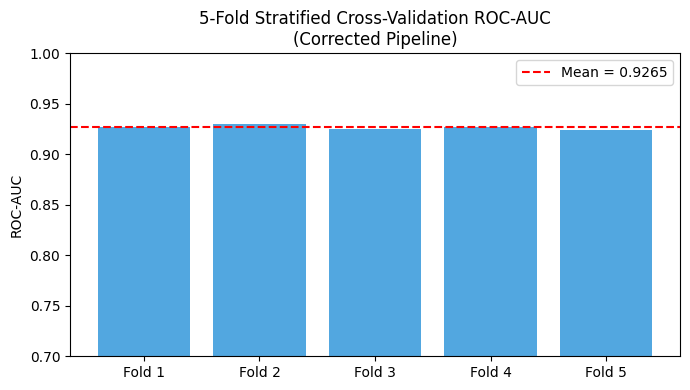

Saved: figures/Claude/fig_18_cv_scores_corrected.png


In [9]:
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.bar(range(1, 6), cv_scores, color='#3498db', alpha=0.85)
ax2.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax2.set_xticks(range(1, 6))
ax2.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax2.set_ylabel('ROC-AUC')
ax2.set_ylim(0.7, 1.0)
ax2.set_title('5-Fold Stratified Cross-Validation ROC-AUC\n(Corrected Pipeline)')
ax2.legend()
plt.tight_layout()
save_and_show(fig2, 'cv_scores_corrected')

## 6. Confusion Matrix and ROC Curve

Comprehensive evaluation of the corrected pipeline on the held-out test set.

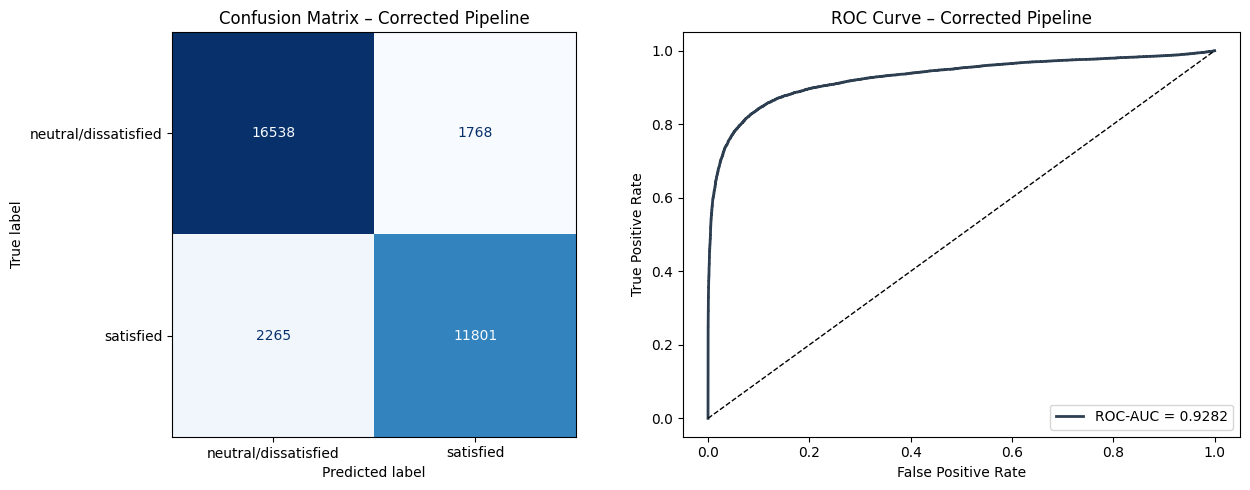

Saved: figures/Claude/fig_19_confusion_matrix_and_roc.png


In [10]:
fig3, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['neutral/dissatisfied', 'satisfied'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Corrected Pipeline')

# ROC curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
auc_val = roc_auc_score(y_te, y_prob)
axes[1].plot(fpr, tpr, color='#2c3e50', lw=2, label=f'ROC-AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve – Corrected Pipeline')
axes[1].legend(loc='lower right')

plt.tight_layout()
save_and_show(fig3, 'confusion_matrix_and_roc')

## Summary

| Issue | Original | Corrected |
|-------|----------|-----------|
| Data path | Wrong file | `Claude_clean.csv` |
| Scaler fit | On full dataset (leakage) | On training set only |
| Categorical encoding | Missing (would error) | `pd.get_dummies` |
| `id` column | Included | Dropped |
| Cross-validation | None | 5-fold stratified CV |
| Evaluation | Accuracy only | Accuracy, ROC-AUC, F1, precision, recall, confusion matrix, ROC curve |

The corrected pipeline follows sound ML practice: **split first, fit preprocessing only on training data, evaluate comprehensively**.